## BUSCO output analysis
In this notebook, we will perform a basic BUSCO analysis.

In [16]:
import sys,os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [17]:
# set paths
BUSCO_RES_FOLDER = '/vol/Topic4CommonData/Module1/precomputed_output/busco/'
MAPPING_PATH = '/vol/Topic4CommonData/Module1/proteome_list.txt'
OUT_PATH = '~/SIBBiodiversitySummerSchool2026Topic4/Module1_AnnotationQuality/out/busco/analysis/'
# TEST PATHS
BUSCO_RES_FOLDER = '/Users/spascare/data/work/dessimoz/teaching/2026/accessory_SIBBS/CommonDataModule1/precomputed_output/minidataset/busco/'
MAPPING_PATH = '/Users/spascare/data/work/dessimoz/teaching/2026/SIBBiodiversitySummerSchool2026Topic4/CommonData/proteome_list.txt'
OUT_PATH = '/Users/spascare/data/work/dessimoz/teaching/2026/SIBBiodiversitySummerSchool2026Topic4/Module1_AnnotationQuality/out/busco/analysis/'
if not os.path.exists(OUT_PATH):
    os.makedirs(OUT_PATH)

# Summary stacked bar plot
we will print the basic statistics for all the busco runs. Write here a plot that captures the basic BUSCO statistics found in the short summary file and plot it as an annotated bar plot. In alternative, you can collect all *short_summary.specific* files in a folder and create the plot with `busco --plot DIRECTORY` instead (remember to mount the correct folder if you are using docker).

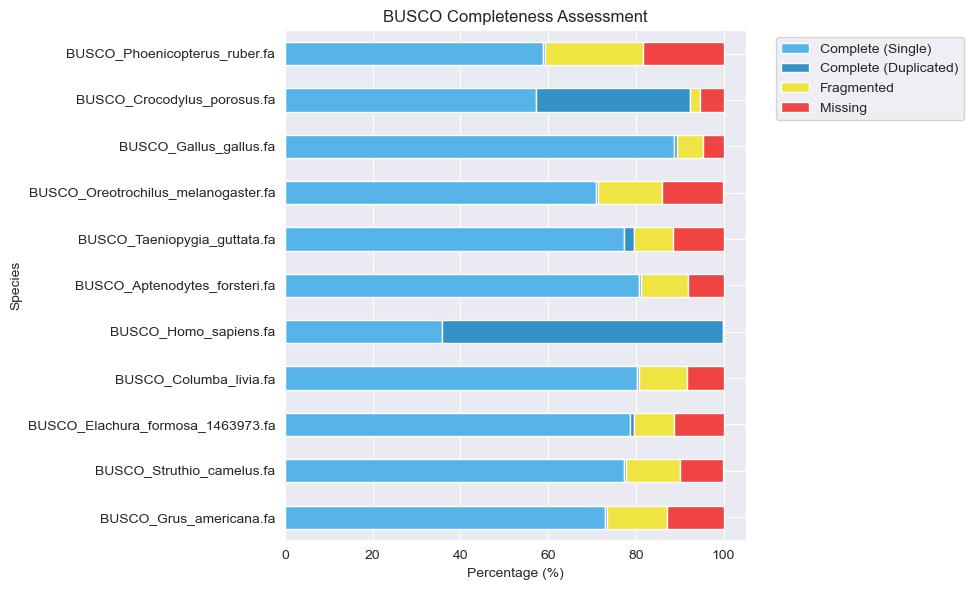

In [18]:
summary_data = []
proteomes = [prot for prot in next(os.walk(BUSCO_RES_FOLDER))[1]]
for species in proteomes:
    species_dir = os.path.join(BUSCO_RES_FOLDER, species)
    # Search for the JSON summary file in the species directory
    json_files = glob.glob(os.path.join(species_dir, 'short_summary*.json'))
    if json_files:
        with open(json_files[0], 'r') as f:
            data = json.load(f)
            # Standard keys for BUSCO v5
            summary_data.append({
                'Species': species,
                'Complete_Single': data['results'].get('Single copy percentage', 0),
                'Complete_Duplicated': data['results'].get('Multi copy percentage', 0),
                'Fragmented': data['results'].get('Fragmented percentage', 0),
                'Missing': data['results'].get('Missing percentage', 0)
            })

# Create DataFrame
df_summary = pd.DataFrame(summary_data).set_index('Species')

# Plot the stacked bar chart
ax = df_summary.plot(kind='barh', stacked=True, figsize=(10, 6), 
                     color=['#56b4e9', '#3492c7', '#f0e442', '#f04442'])

plt.title('BUSCO Completeness Assessment')
plt.xlabel('Percentage (%)')
plt.legend(['Complete (Single)', 'Complete (Duplicated)', 'Fragmented', 'Missing'], 
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save and show
plt.savefig(os.path.join(OUT_PATH, 'busco_summary_plot.png'), dpi=300)
plt.show()

# Filter proteome by completeness
Here we will create a basic filter to select those proteomes that pass a certain threshold of completeness

In [22]:
# Calculate Total Complete (Single + Duplicated)
df_summary['Total_Complete'] = df_summary['Complete_Single'] + df_summary['Complete_Duplicated']

# Set your strictness threshold
THRESHOLD = 50.0  

# Filter the DataFrame
high_quality = df_summary[df_summary['Total_Complete'] >= THRESHOLD]

print(f"--- Quality Filter (Threshold: {THRESHOLD}%) ---")
print(f"Total proteomes passing: {len(high_quality)} / {len(df_summary)}")
print("Retained species:")
print(high_quality.index.tolist())

--- Quality Filter (Threshold: 50.0%) ---
Total proteomes passing: 11 / 11
Retained species:
['BUSCO_Grus_americana.fa', 'BUSCO_Struthio_camelus.fa', 'BUSCO_Elachura_formosa_1463973.fa', 'BUSCO_Columba_livia.fa', 'BUSCO_Homo_sapiens.fa', 'BUSCO_Aptenodytes_forsteri.fa', 'BUSCO_Taeniopygia_guttata.fa', 'BUSCO_Oreotrochilus_melanogaster.fa', 'BUSCO_Gallus_gallus.fa', 'BUSCO_Crocodylus_porosus.fa', 'BUSCO_Phoenicopterus_ruber.fa']


# top100 BUSCOs presence/absence heatmap
here we will create a heatmap with BUSCO presence absence per species


/var/folders/k5/g6s14m0d2s9czvty1s0x8rcw0000gp/T/ipykernel_81843/946635248.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df_matrix.replace(status_map)


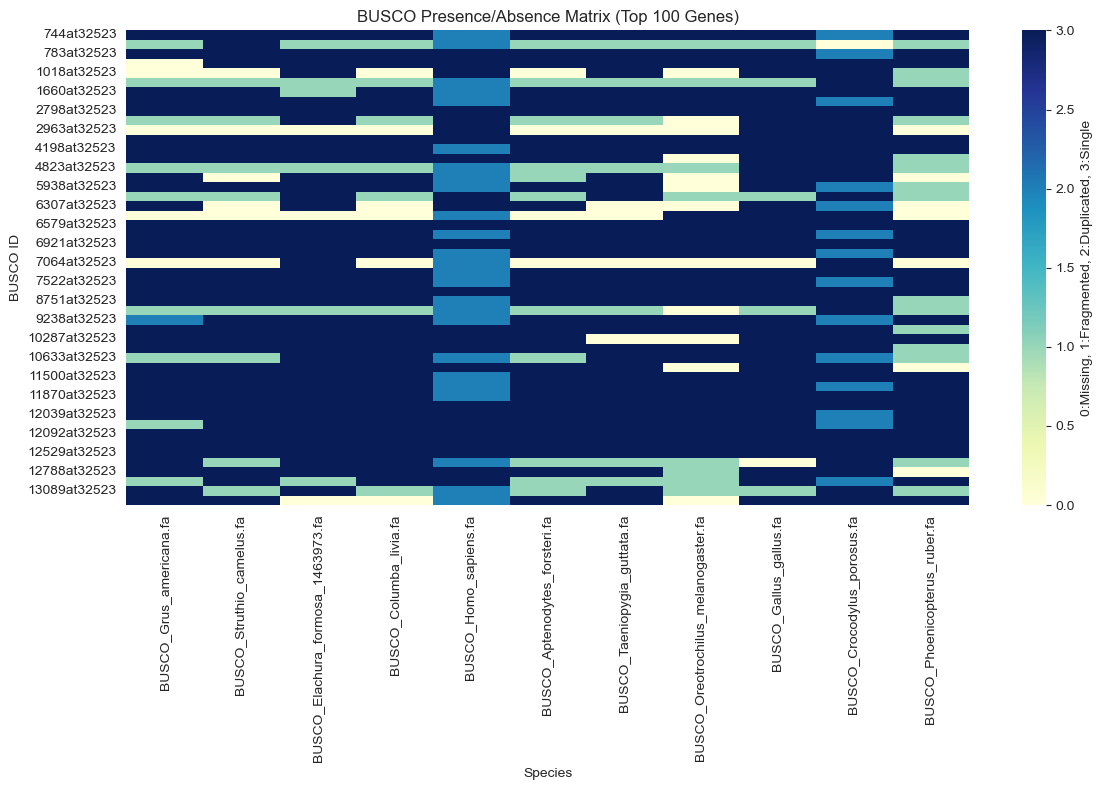

In [57]:
matrix_dict = {}

for species in proteomes:
    # Locate the full table TSV. Adjust the glob pattern if your directory structure differs slightly.
    table_path = os.path.join(BUSCO_RES_FOLDER, species, 'run_tetrapoda_odb12.2', 'full_table.tsv')
    
    if os.path.exists(table_path):
        # Read the TSV, skipping the comment headers
        df_full = pd.read_csv(table_path, sep='\t', comment='#', header=None, index_col=False,
                              names=['Busco_id', 'Status', 'Sequence', 'Score', 'Length', 'OrthoDB_url', 'Description'])
        # Since all duplicates have 'Duplicated' as their status, keeping the first one is perfectly safe.
        df_dedup = df_full.drop_duplicates(subset=['Busco_id'])
        # Store the status indexed by the BUSCO ID
        matrix_dict[species] = df_dedup.set_index('Busco_id')['Status']
        

# Build the master matrix and fill gaps with 'Missing'
df_matrix = pd.DataFrame(matrix_dict).fillna('Missing')

# Map statuses to integers for heatmap coloring
status_map = {'Complete': 3, 'Duplicated': 2, 'Fragmented': 1, 'Missing': 0}
df_numeric = df_matrix.replace(status_map)

# Plot Heatmap (showing just the first 100 genes to prevent visual overloading)
plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.head(50), cmap="YlGnBu", cbar_kws={'label': '0:Missing, 1:Fragmented, 2:Duplicated, 3:Single'})
plt.title('BUSCO Presence/Absence Matrix (Top 100 Genes)')
plt.xlabel('Species')
plt.ylabel('BUSCO ID')
plt.tight_layout()

plt.savefig(os.path.join(OUT_PATH, 'busco_presence_heatmap.png'), dpi=300)
plt.show()

In [ ]:
# extract single copy orthologs

In [ ]:
# Filter the master matrix for rows where ALL columns equal 'Single'
# (If you only want to use the high_quality species, change df_matrix to df_matrix[high_quality.index])
core_genes = df_matrix[(df_matrix == 'Single').all(axis=1)]

print(f"Found {len(core_genes)} universal single-copy orthologs across all analyzed species.")
print("\nSample of Core Gene IDs:")
print(core_genes.index.tolist()[:10])

# Save this list to a file to feed into your downstream alignment/tree tools
core_genes_path = os.path.join(OUT_PATH, 'core_single_copy_buscos.txt')
with open(core_genes_path, 'w') as f:
    for busco_id in core_genes.index:
        f.write(f"{busco_id}\n")

print(f"\nSaved core gene ID list to: {core_genes_path}")